# Exploration phase for developing the model

## 1. Imports

In [61]:
from typing import Tuple
import os
from dotenv import load_dotenv
import pyarrow
from pathlib import Path
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
load_dotenv()
os.getenv('AWS_ACCESS_KEY_ID') is not None

True

## 2. Data set loading

In [30]:
s3 = boto3.client('s3')

BUCKET = 'zrive-ds-data'
PREFIX = 'groceries/box_builder_dataset/'

response = s3.list_objects_v2(
    Bucket = BUCKET,
    Prefix = PREFIX
)

key = response['Contents'][0]['Key']
filename = response['Contents'][0]['Key'].split('/')[-1]

local_data_dir = Path('../../data/module3')
local_path = local_data_dir/filename

if local_path.exists():
        print(f'{filename} already exists')
else:
    print(f'Downloading: {filename}')
    s3.download_file(BUCKET,key,local_path)

feature_frame.csv already exists


In [31]:
df_original= pd.read_csv(local_path)
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [32]:
df_original.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [33]:
df = df_original.copy()

## 3. Data Set cleaning

In [88]:
info_cols = ["variant_id", "order_id", "user_id", "created_at", "order_date" ]
target_cols = "outcome"
feature_cols = [col for col in df.columns if col not in info_cols + [target_cols]]

categorical_cols = ["vendor", "product_type"]
binary_cols = ["ordered_before","active_snoozed", "abandoned_before","set_as_regular"]
numerical_cols = [col for col in feature_cols if col not in categorical_cols + binary_cols]

In [35]:
def create_wanted_df(df:pd.DataFrame, min_products: int = 5) -> pd.DataFrame:
    """we want only orders with more than five products"""
    order_size = df.groupby("order_id")["outcome"].sum()
    orders_wanted = order_size[order_size >= min_products].index
    return df.loc[lambda x: x.order_id.isin(orders_wanted)]


def format_date_cols(df: pd.DataFrame) -> pd.DataFrame:
    return(
        df
        .assign(created_at = lambda x: pd.to_datetime(x.created_at))
        .assign(order_date = lambda x: pd.to_datetime(x.order_date).dt.date)

    )

df_selected = (
    df.pipe(create_wanted_df)
    .pipe(format_date_cols)
)


In [36]:
df.order_id.nunique() > df_selected.order_id.nunique()

True

In [37]:
df_selected.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
5,33826472919172,ricepastapulses,2808434524292,3479090790532,2020-10-06 10:50:23,2020-10-06,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [56]:
df_selected[['global_popularity']].head()

,global_popularity
714957,0.016317
1444958,0.016908
1750923,0.006993
673394,0.012894
2641579,0.003273


In [38]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2163953 entries, 0 to 2880547
Data columns (total 27 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   variant_id                        int64         
 1   product_type                      object        
 2   order_id                          int64         
 3   user_id                           int64         
 4   created_at                        datetime64[ns]
 5   order_date                        object        
 6   user_order_seq                    int64         
 7   outcome                           float64       
 8   ordered_before                    float64       
 9   abandoned_before                  float64       
 10  active_snoozed                    float64       
 11  set_as_regular                    float64       
 12  normalised_price                  float64       
 13  discount_pct                      float64       
 14  vendor                 

In [39]:
df_selected = df_selected.sample(n=100000, random_state = 42)

For memory optimization purposes,and taking into account that we will use linear models, we will reduce the data set length from 2M rows to 50k, as they should be enough to get a good training fit, while getting good speed of processing.

We won't encode categorical variables yet, as we will try to follow an incremental training on the model, to determine if its performance increases in a reasonable way when adding the categorical variables so that it is worth it to use them and process them.

## Model selection and evaluation

In [77]:
from sklearn.metrics import precision_recall_curve,auc
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier

### Data split and scale

We will remove variant_id, order_id and user_id as well as the variables encoded and tranformed into datetime.
- order id was only used for filtering
- variant_id and user_id are integers, so the model would assign coefficients to them as if they were numerical variables, what makes no sense, and hot-encoding them would generate an extreme number of extra-columns.
- Must be also taken into account that information regarding user_id and variant_id is already contained in the rest of the columns, such as user_order_seq, ordered_before, or avs_days_to_buy_variant_id.


In order to perform the train test split, we first must think about weteher tf might be any type of information leakage due to the time nature of our data, and indeed, there is. We can not train the model with data that is older than the data it will have to predict later, as this is not what is goint to happen in real production.

In [40]:
daily_orders = df_selected.groupby("order_date").order_id.nunique()

In [41]:
daily_orders.head()

order_date
2020-10-05     3
2020-10-06     7
2020-10-07     6
2020-10-08    12
2020-10-09     4
Name: order_id, dtype: int64

Text(0.5, 1.0, 'Daily_orders')

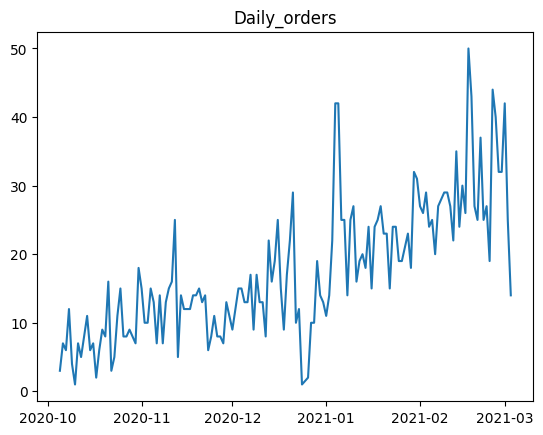

In [43]:
plt.plot(daily_orders, label = "daily_orders")
plt.title("Daily_orders")

As we can see, apart from the time-nature information leakage we would have if we do not do a temporal split, we also conclude that there ir a time-evolution on the purchase behaviour, probably due to the evolution and growth of the business.

Therefore, this is another reason for making a temporal split, as we can not train the model with the purchase tendency of the future when predicting a user order from the past.

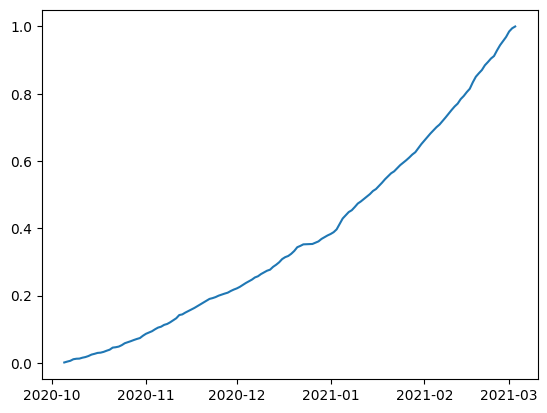

In [45]:
cumsum_daily_orders = daily_orders.cumsum()/daily_orders.sum()
plt.plot(cumsum_daily_orders)

In [46]:
train_cutoff = cumsum_daily_orders[cumsum_daily_orders<=0.7].idxmax()
val_cutoff = cumsum_daily_orders[cumsum_daily_orders<=0.9].idxmax()


In [49]:
df_train = df_selected[df_selected.order_date <= train_cutoff]

df_val = df_selected[
    (df_selected.order_date > train_cutoff)
    & (df_selected.order_date <= val_cutoff)
]

df_test = df_selected[df_selected.order_date > val_cutoff]

[]

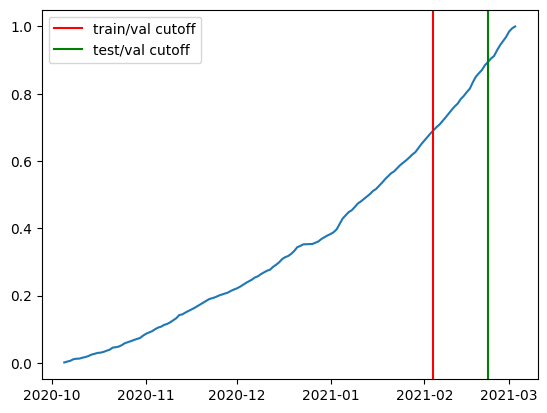

In [51]:
plt.plot(cumsum_daily_orders)
plt.axvline(train_cutoff, color = 'red', label = "train/val cutoff")
plt.axvline(val_cutoff, color = 'green', label = "test/val cutoff")
plt.legend()
plt.plot()

### BASELINE

In order to develop a model, we should have something to compare against, something simple, to justify the implementation of a more complex ML model.

In this case, I will develop 2 baselines:
1. Using the `global_popularity` feature
2. Using a random linear classifier without penalization

In [75]:
def plot_metrics(
        model_name: str,
        y_pred: pd.Series,
        y_test: pd.Series,
        target_precision: float = 0.05,
        figure: Tuple[matplotlib.figure.Figure, np.array] = None
):
    precision, recall,_ = precision_recall_curve(y_test,y_pred)
    pr_auc = auc(recall, precision)

    fpr, tpr,_ = roc_curve(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_pred)
    
    if figure is None:
        fig, ax = plt.subplots(1,2,figsize = (14,7))
    else:
        fig,ax = figure

    ax[0].plot(recall,precision,label = f"{model_name}; AUC: {pr_auc:.2f}") 
    ax[0].set_xlabel('recall')
    ax[0].set_ylabel('precision')
    ax[0].set_title('Precision-recall curve')
    ax[0].legend()

    ax[1].plot(fpr,tpr,label = f"{model_name}; AUC: {roc_auc:.2f}") 
    ax[1].set_xlabel('False positive rate')
    ax[1].set_ylabel('True positive rate')
    ax[1].set_title('ROC curve')
    ax[1].legend()





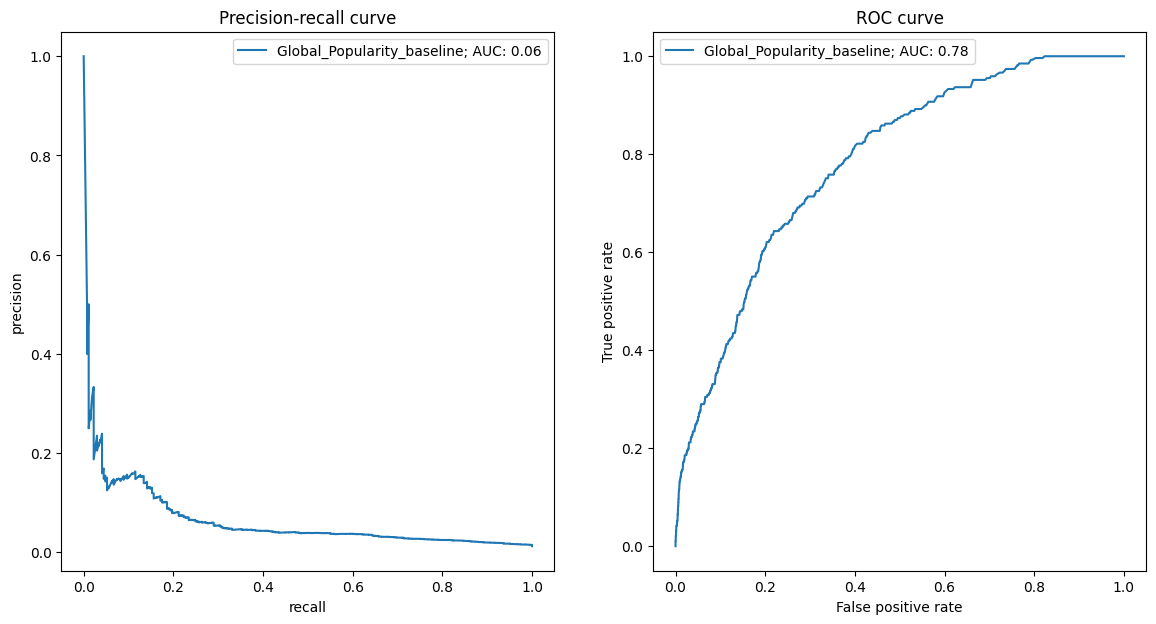

In [76]:
plot_metrics(
    "Global_Popularity_baseline",y_pred = df_val.global_popularity,y_test = df_val[target_cols]
)

In [89]:
def feature_split(
        df: pd.DataFrame, target_col: str
) -> Tuple[pd.DataFrame, pd.Series]:
    return df.drop(columns = target_col), df[target_col]

X_train, y_train = feature_split(df_train,target_cols)
X_val, y_val = feature_split(df_val,target_cols)
X_test, y_test = feature_split(df_test,target_cols)

In [90]:
model = DummyClassifier(strategy="prior", random_state = 42)

model.fit(X_train,y_train)
y_pred = model.predict_proba(X_val)[:,1]

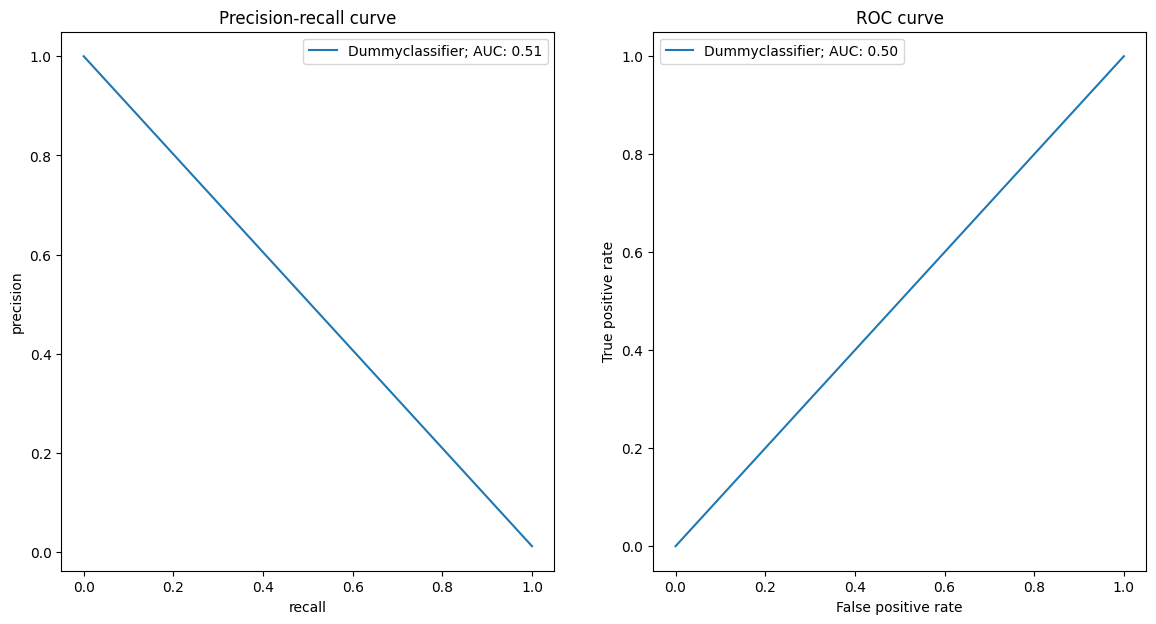

In [91]:
plot_metrics(
    "Dummyclassifier", y_pred = y_pred, y_test = y_val
)

We can see in the ROC AUC that the global popularity baseline will be harder to beat.

### Model Trainig

In [93]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In order to follow the incremental training we already mentioned, we will start by only using the numericla and binary columns for training

In [92]:
training_cols = numerical_cols + binary_cols

/home/pablomartin/.cache/pypoetry/virtualenvs/zrive-ds-VI-NehdI-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/pablomartin/.cache/pypoetry/virtualenvs/zrive-ds-VI-NehdI-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/pablomartin/.cache/pypoetry/virtualenvs/zrive-ds-VI-NehdI-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/pablomartin/.cache/pypoetry/virtualenvs/zrive-ds-VI-NehdI-py3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/pablomartin/.cache/pypoetry/virtualenvs/zrive-ds-VI-NehdI-py3.

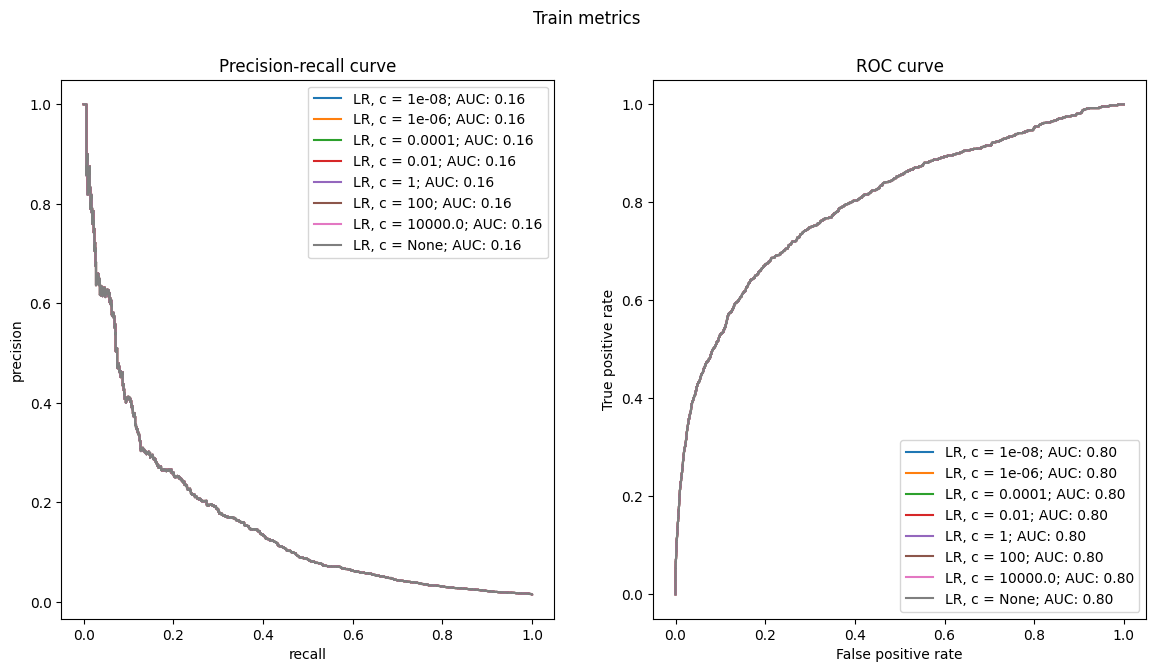

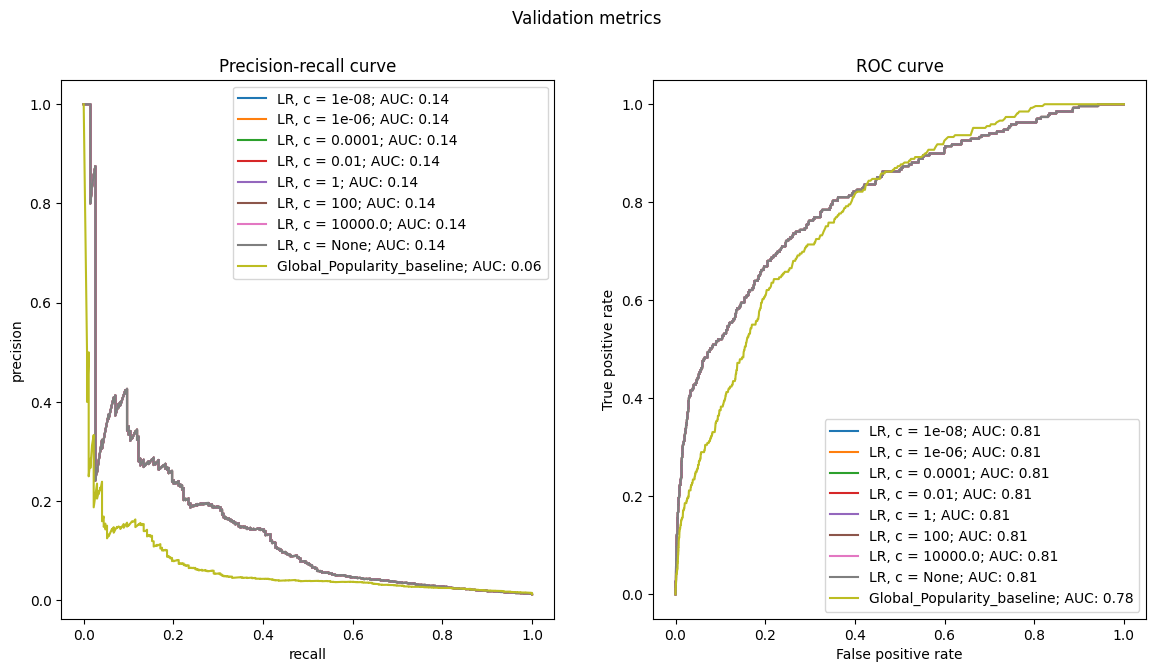

In [101]:



fig1,ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle("Train metrics")

fig2,ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle("Validation metrics")

Cs = [1e-8,1e-6,1e-4,1e-2,1,100,1e4,None]

for c in Cs:
    lr = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty= None,C=c if c else 1.0)
    )

    lr.fit(X_train[training_cols],y_train)

    train_proba = lr.predict_proba(X_train[training_cols])[:,1]
    plot_metrics(
        f"LR, c = {c}", y_pred=train_proba, y_test = y_train, figure = (fig1,ax1)
    )

    val_proba = lr.predict_proba(X_val[training_cols])[:,1]
    plot_metrics(
        f"LR, c = {c}", y_pred=val_proba, y_test = y_val, figure = (fig2,ax2)
    )

plot_metrics(
    "Global_Popularity_baseline",y_pred = df_val.global_popularity,y_test = df_val[target_cols], figure = (fig2,ax2)
)


### Lasso

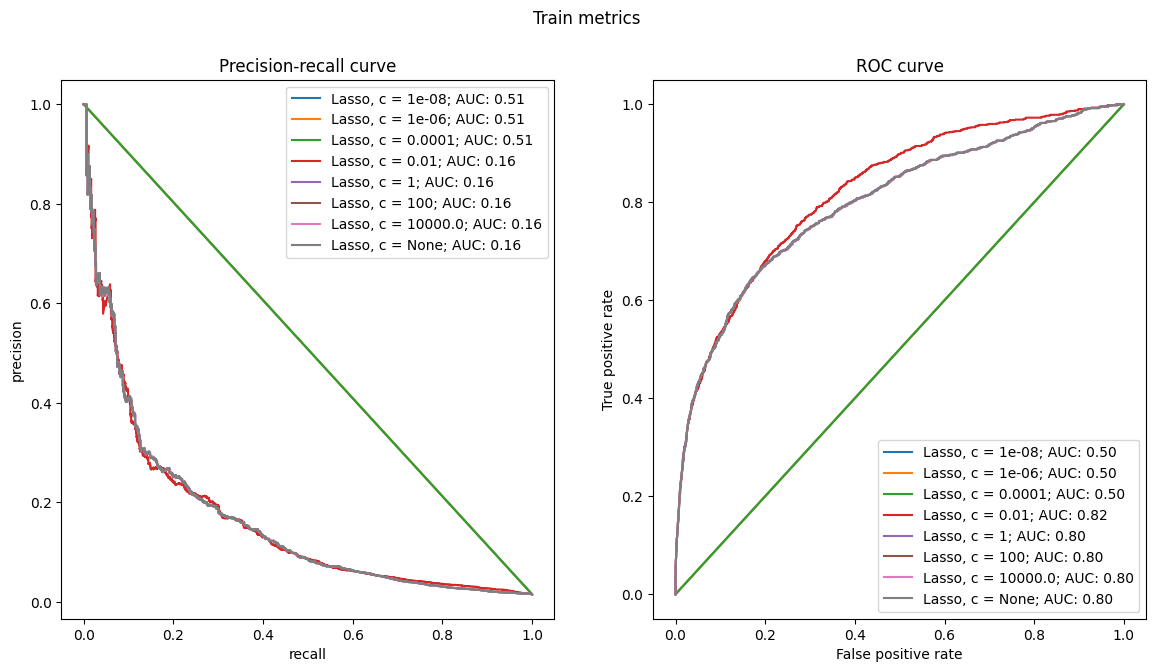

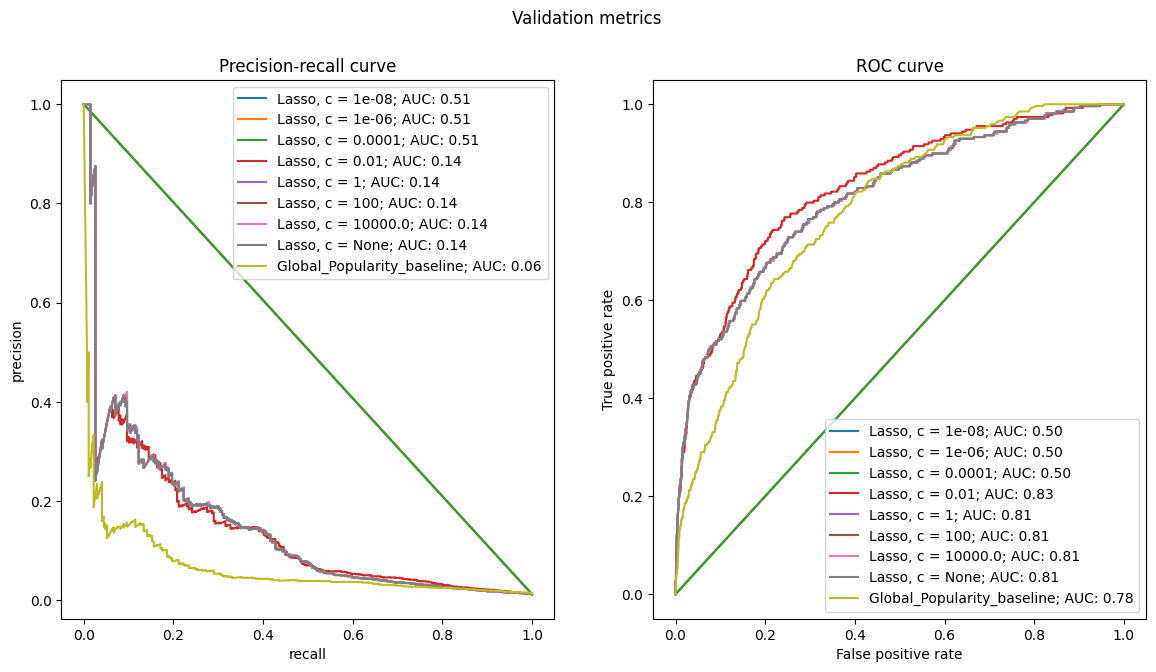

In [102]:
fig1,ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle("Train metrics")

fig2,ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle("Validation metrics")

Cs = [1e-8,1e-6,1e-4,1e-2,1,100,1e4,None]

for c in Cs:
    lr = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=c if c else 1.0,solver="saga")
    )

    lr.fit(X_train[training_cols],y_train)

    train_proba = lr.predict_proba(X_train[training_cols])[:,1]
    plot_metrics(
        f"Lasso, c = {c}", y_pred=train_proba, y_test = y_train, figure = (fig1,ax1)
    )

    val_proba = lr.predict_proba(X_val[training_cols])[:,1]
    plot_metrics(
        f"Lasso, c = {c}", y_pred=val_proba, y_test = y_val, figure = (fig2,ax2)
    )

plot_metrics(
    "Global_Popularity_baseline",y_pred = df_val.global_popularity,y_test = df_val[target_cols], figure = (fig2,ax2)
)

### Ridge

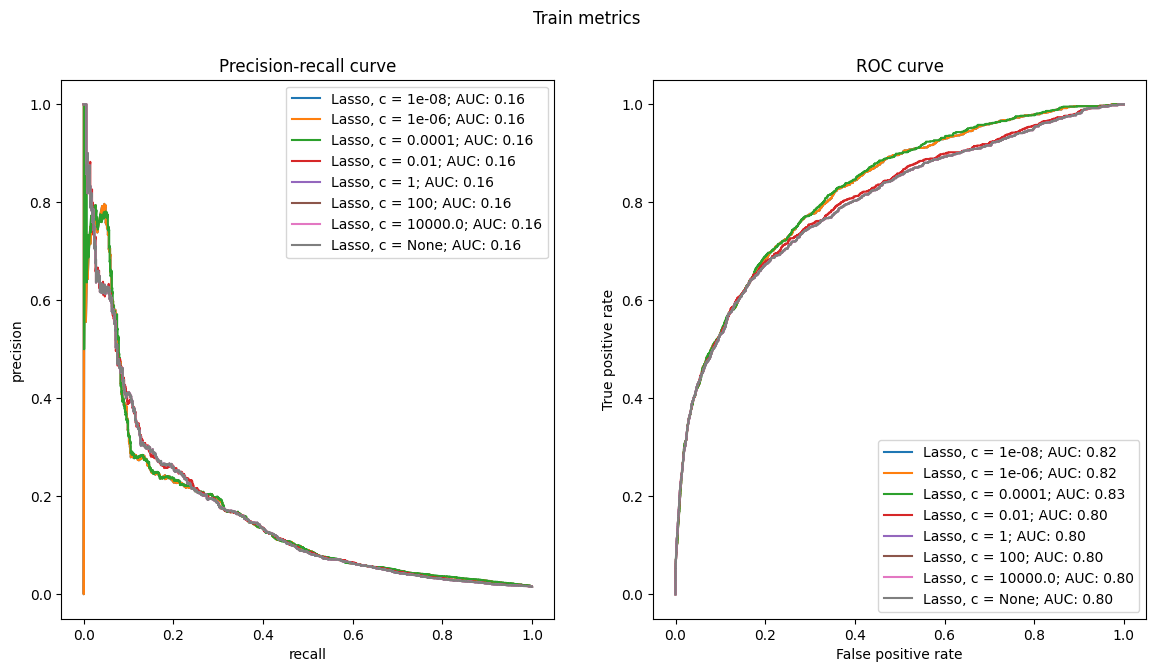

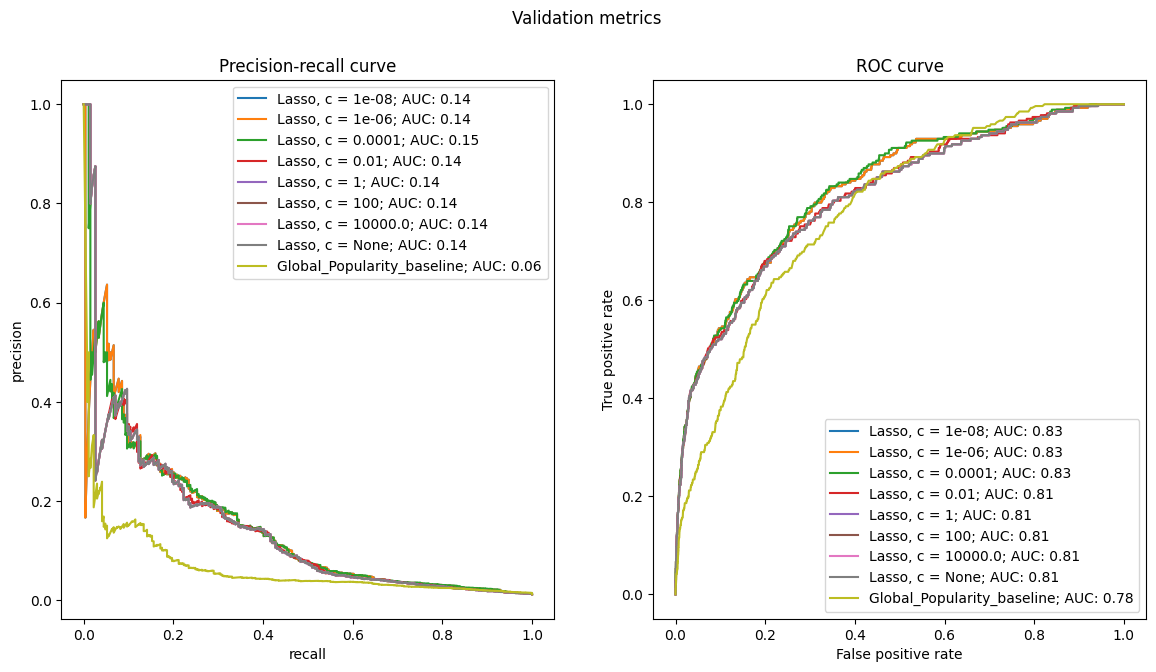

In [100]:
fig1,ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle("Train metrics")

fig2,ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle("Validation metrics")

Cs = [1e-8,1e-6,1e-4,1e-2,1,100,1e4,None]

for c in Cs:
    lr = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=c if c else 1.0)
    )

    lr.fit(X_train[training_cols],y_train)

    train_proba = lr.predict_proba(X_train[training_cols])[:,1]
    plot_metrics(
        f"Lasso, c = {c}", y_pred=train_proba, y_test = y_train, figure = (fig1,ax1)
    )

    val_proba = lr.predict_proba(X_val[training_cols])[:,1]
    plot_metrics(
        f"Lasso, c = {c}", y_pred=val_proba, y_test = y_val, figure = (fig2,ax2)
    )

plot_metrics(
    "Global_Popularity_baseline",y_pred = df_val.global_popularity,y_test = df_val[target_cols], figure = (fig2,ax2)
)